# EDA - RetailRocket ecommerce dataset

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 4)
sns.set_style('whitegrid')

DATA_DIR = '../data'

In [2]:
events = pd.read_csv(os.path.join(DATA_DIR, 'events.csv'))
events['timestamp'] = pd.to_datetime(events['timestamp'], unit='ms')
print('строк:', len(events))
print()
print('пропуски:')
print(events.isna().sum())
events.head()

строк: 2756101

пропуски:
timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64


,timestamp,visitorid,event,itemid,transactionid
0,2015-06-02 05:02:12.117,257597,view,355908,NaN
1,2015-06-02 05:50:14.164,992329,view,248676,NaN
2,2015-06-02 05:13:19.827,111016,view,318965,NaN
3,2015-06-02 05:12:35.914,483717,view,253185,NaN
4,2015-06-02 05:02:17.106,951259,view,367447,NaN


## Типы событий и воронка

In [3]:
cnt = events['event'].value_counts()
print(cnt)
print()
print('% от view:')
print((cnt / cnt['view'] * 100).round(2))

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

% от view:
event
view           100.00
addtocart        2.60
transaction      0.84
Name: count, dtype: float64


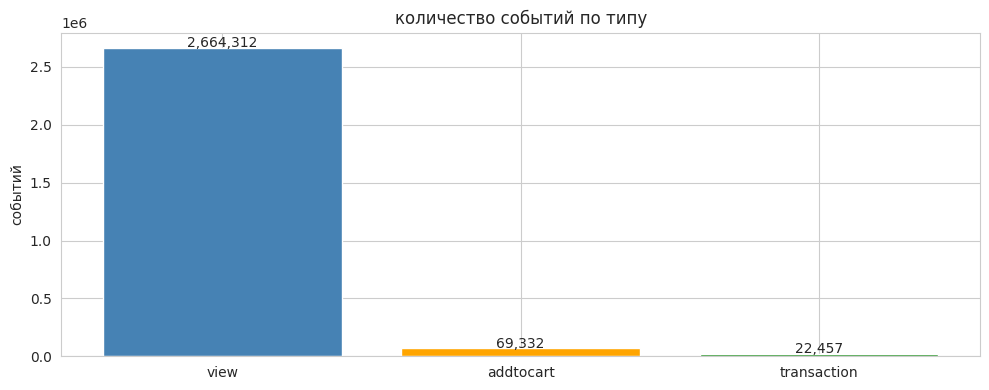

In [4]:
fig, ax = plt.subplots()
ax.bar(cnt.index, cnt.values, color=['steelblue', 'orange', 'green'])
for i, (k, v) in enumerate(cnt.items()):
    ax.text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)
ax.set_title('количество событий по типу')
ax.set_ylabel('событий')
plt.tight_layout()
plt.show()

In [5]:
uniq_v = events[events['event'] == 'view']['visitorid'].nunique()
uniq_a = events[events['event'] == 'addtocart']['visitorid'].nunique()
uniq_t = events[events['event'] == 'transaction']['visitorid'].nunique()

print(f'view:        {uniq_v:,}')
print(f'addtocart:   {uniq_a:,}  ({uniq_a/uniq_v*100:.1f}% от view)')
print(f'transaction: {uniq_t:,}  ({uniq_t/uniq_v*100:.1f}% от view)')

view:        1,404,179
addtocart:   37,722  (2.7% от view)
transaction: 11,719  (0.8% от view)


большинство пользователей только смотрят, до корзины доходят единицы. для модели берем addtocart + transaction, view не трогаем - слишком шумный.

## Временная динамика

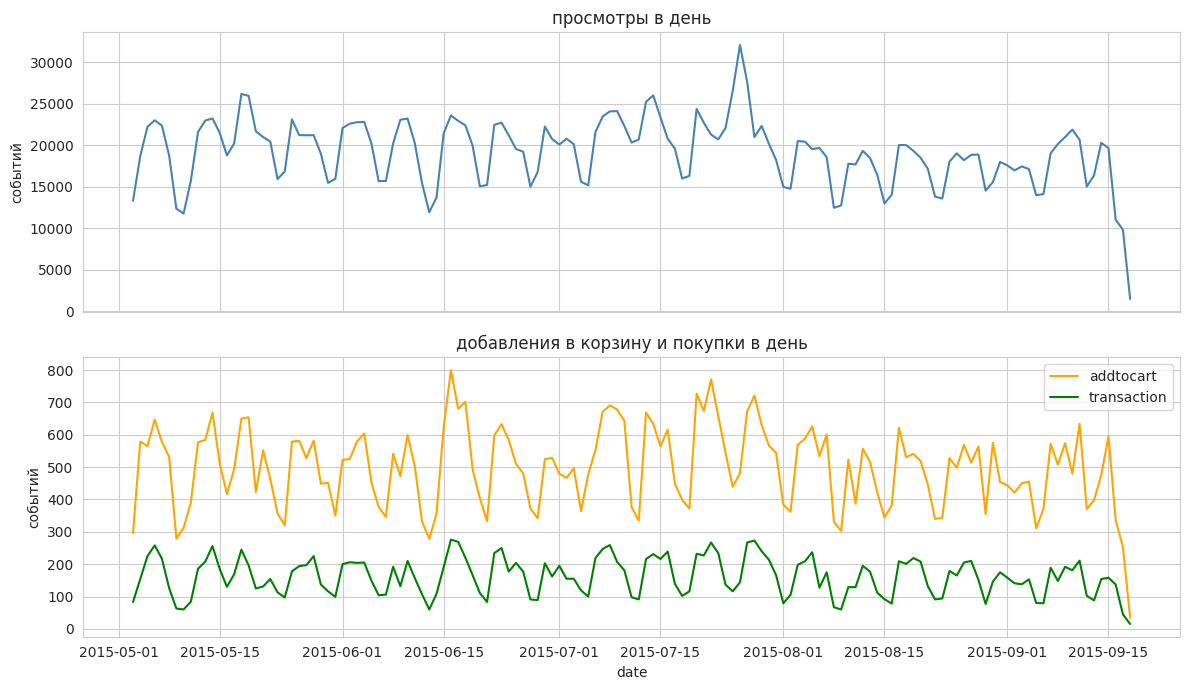

In [6]:
events['date'] = events['timestamp'].dt.date
daily = events.groupby(['date', 'event']).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
daily['view'].plot(ax=axes[0], color='steelblue')
axes[0].set_title('просмотры в день')
axes[0].set_ylabel('событий')

daily[['addtocart', 'transaction']].plot(ax=axes[1], color=['orange', 'green'])
axes[1].set_title('добавления в корзину и покупки в день')
axes[1].set_ylabel('событий')
axes[1].legend()
plt.tight_layout()
plt.show()

## Активность пользователей

In [7]:
user_events = events.groupby('visitorid').size()
print('событий на пользователя:')
print(user_events.describe().round(1))
print()
print('% пользователей с 1 событием:', round((user_events == 1).mean() * 100, 1))
print('% пользователей с >=10 событиями:', round((user_events >= 10).mean() * 100, 1))

событий на пользователя:
count    1407580.0
mean           2.0
std           12.6
min            1.0
25%            1.0
50%            1.0
75%            2.0
max         7757.0
dtype: float64

% пользователей с 1 событием: 71.2
% пользователей с >=10 событиями: 1.7


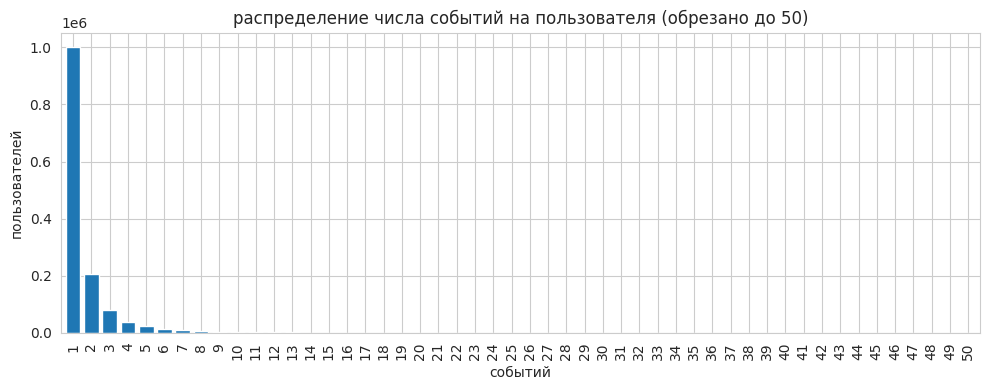

In [8]:
fig, ax = plt.subplots()
user_events.clip(upper=50).value_counts().sort_index().plot(kind='bar', ax=ax, width=0.8)
ax.set_title('распределение числа событий на пользователя (обрезано до 50)')
ax.set_xlabel('событий')
ax.set_ylabel('пользователей')
plt.tight_layout()
plt.show()

длинный хвост: большинство заходят раз-два и уходят. для них нет истории - будем отдавать топ популярных.

## Популярность товаров

In [9]:
item_events = events.groupby('itemid').size().sort_values(ascending=False)
print('топ-10 товаров по числу событий:')
print(item_events.head(10))
print()
print('% товаров с >=10 событиями:', round((item_events >= 10).mean() * 100, 1))
top1pct = item_events.head(len(item_events) // 100).sum()
print('% событий на топ-1% товаров:', round(top1pct / len(events) * 100, 1))

топ-10 товаров по числу событий:
itemid
187946    3412
461686    2978
5411      2334
370653    1854
219512    1800
257040    1647
298009    1642
96924     1633
309778    1628
384302    1608
dtype: int64

% товаров с >=10 событиями: 23.5
% событий на топ-1% товаров: 22.9


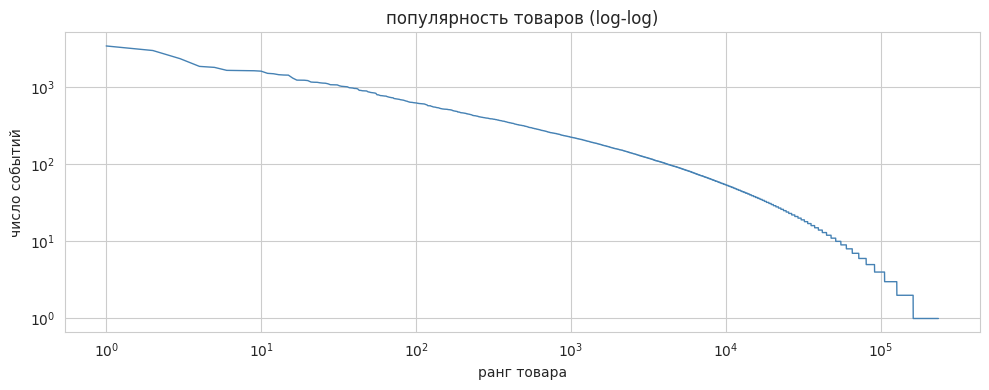

In [10]:
fig, ax = plt.subplots()
ax.loglog(range(1, len(item_events) + 1), item_events.values, color='steelblue', lw=1)
ax.set_title('популярность товаров (log-log)')
ax.set_xlabel('ранг товара')
ax.set_ylabel('число событий')
plt.tight_layout()
plt.show()

степенной закон - топ-1% товаров собирает большую часть событий.

## Категории

In [11]:
cats = pd.read_csv(os.path.join(DATA_DIR, 'category_tree.csv'))
print('категорий всего:', len(cats))
print('корневых категорий (без родителя):', cats['parentid'].isna().sum())
cats.head()

категорий всего: 1669
корневых категорий (без родителя): 25


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


In [12]:
props_cols = ['itemid', 'property', 'value']
p1 = pd.read_csv(os.path.join(DATA_DIR, 'item_properties_part1.csv'), usecols=props_cols)
p2 = pd.read_csv(os.path.join(DATA_DIR, 'item_properties_part2.csv'), usecols=props_cols)
item_cats = pd.concat([p1[p1['property'] == 'categoryid'],
                       p2[p2['property'] == 'categoryid']])
item_cats = item_cats.groupby('itemid')['value'].last().reset_index()
item_cats.columns = ['itemid', 'categoryid']
item_cats['categoryid'] = pd.to_numeric(item_cats['categoryid'], errors='coerce')
print('товаров с категорией:', len(item_cats))
item_cats.head()

товаров с категорией: 417053


,itemid,categoryid
0,0,209
1,1,1114
2,2,1305
3,3,1171
4,4,1038


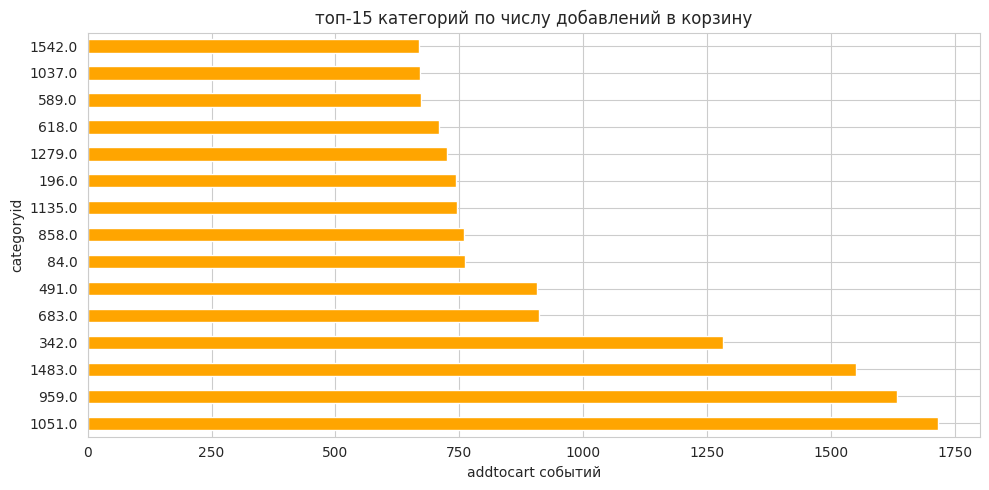

In [13]:
add = events[events['event'] == 'addtocart'].merge(item_cats, on='itemid', how='left')
top_cats = add['categoryid'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_cats.plot(kind='barh', ax=ax, color='orange')
ax.set_title('топ-15 категорий по числу добавлений в корзину')
ax.set_xlabel('addtocart событий')
plt.tight_layout()
plt.show()

## выводы

- данные ~4 месяца (май-сент 2015)
- view (~97%), addtocart (~2.5%), transaction (~0.8%)
- больше 70% пользователей с одним событием - сильный холодный старт
- активных (>=2 позитивных событий) всего ~16k - на них учим ALS
- веса: transaction=3, addtocart=2
- i2i: косинусное сходство по факторам ALS